# Facebook Engagement Analysis - EDA & Data Wrangling

Author: Nick Peril  
Project: TKH Phase I Portfolio Project   
Dataset: [Facebook Metrics (UCI Repository)](https://archive.ics.uci.edu/dataset/368/facebook+metrics)

## Objective
To explore the dataset and identify patterns that influence post engagement.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading my dataset:

In [3]:
df = pd.read_csv("/Users/saadult/facebook-engagement-analysis/data/raw/dataset_Facebook.csv", sep=';')

Displaying the first 20 rows:

In [4]:
df. head(20)

,Page total likes,Type,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
0,139441,Photo,2,12,4,3,0.0,2752,5091,178,109,159,3078,1640,119,4,79.0,17.0,100
1,139441,Status,2,12,3,10,0.0,10460,19057,1457,1361,1674,11710,6112,1108,5,130.0,29.0,164
2,139441,Photo,3,12,3,3,0.0,2413,4373,177,113,154,2812,1503,132,0,66.0,14.0,80
3,139441,Photo,2,12,2,10,1.0,50128,87991,2211,790,1119,61027,32048,1386,58,1572.0,147.0,1777
4,139441,Photo,2,12,2,3,0.0,7244,13594,671,410,580,6228,3200,396,19,325.0,49.0,393
5,139441,Status,2,12,1,9,0.0,10472,20849,1191,1073,1389,16034,7852,1016,1,152.0,33.0,186
6,139441,Photo,3,12,1,3,1.0,11692,19479,481,265,364,15432,9328,379,3,249.0,27.0,279
7,139441,Photo,3,12,7,9,1.0,13720,24137,537,232,305,19728,11056,422,0,325.0,14.0,339
8,139441,Status,2,12,7,3,0.0,11844,22538,1530,1407,1692,15220,7912,1250,0,161.0,31.0,192
9,139441,Photo,3,12,6,10,0.0,4694,8668,280,183,250,4309,2324,199,3,113.0,26.0,142


In [5]:
df.shape

(500, 19)

The dataset contains 500 rows and 19 columns.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Page total likes                                                     500 non-null    int64  
 1   Type                                                                 500 non-null    object 
 2   Category                                                             500 non-null    int64  
 3   Post Month                                                           500 non-null    int64  
 4   Post Weekday                                                         500 non-null    int64  
 5   Post Hour                                                            500 non-null    int64  
 6   Paid                                                                 499 non-null    float64
 7   Lifetime

The dataset have both numerical and categorical variables.

In [7]:
df.describe().round(2)

,Page total likes,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
count,500.00,500.00,500.00,500.00,500.00,499.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,499.00,496.00,500.00
mean,123194.18,1.88,7.04,4.15,7.84,0.28,13903.36,29585.95,920.34,798.77,1415.13,16766.38,6585.49,609.99,7.48,177.95,27.27,212.12
std,16272.81,0.85,3.31,2.03,4.37,0.45,22740.79,76803.25,985.02,882.51,2000.59,59791.02,7682.01,612.73,21.18,323.40,42.61,380.23
min,81370.00,1.00,1.00,1.00,1.00,0.00,238.00,570.00,9.00,9.00,9.00,567.00,236.00,9.00,0.00,0.00,0.00,0.00
25%,112676.00,1.00,4.00,2.00,3.00,0.00,3315.00,5694.75,393.75,332.50,509.25,3969.75,2181.50,291.00,1.00,56.50,10.00,71.00
50%,129600.00,2.00,7.00,4.00,9.00,0.00,5281.00,9051.00,625.50,551.50,851.00,6255.50,3417.00,412.00,3.00,101.00,19.00,123.50
75%,136393.00,3.00,10.00,6.00,11.00,1.00,13168.00,22085.50,1062.00,955.50,1463.00,14860.50,7989.00,656.25,7.00,187.50,32.25,228.50
max,139441.00,3.00,12.00,7.00,23.00,1.00,180480.00,1110282.00,11452.00,11328.00,19779.00,1107833.00,51456.00,4376.00,372.00,5172.00,790.00,6334.00


### Key Observations from Descriptive Statistics:
1. There are missing values in the following columns: 'Paid', 'like', and 'share'. This means we need to clean this dataset and decide how to treat the missing values.
2. The mean interactions is only slightly above the median. Only few posts are getting viral inflating the average.
3. The min interaction is 0.000, means there are post that has no interaction at all. Maybe related to post visibility (ie. private, hidden).
4. The max interactions will tell the range from the min, there is a huge gap - it may mean outliers.

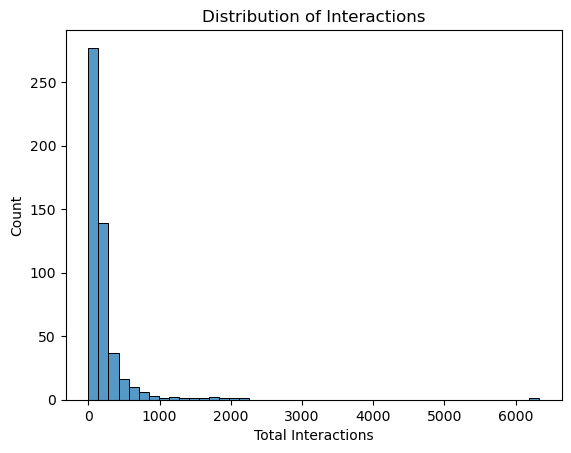

In [22]:
plt.figure()
sns.histplot(df['Total Interactions'])
plt.title("Distribution of Interactions")
plt.show()

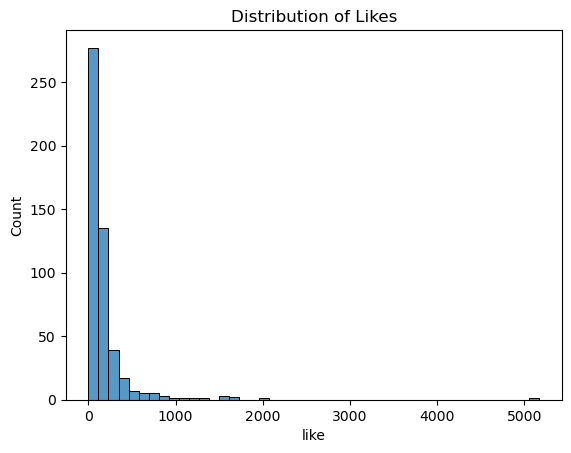

In [23]:
plt.figure()
sns.histplot(df['like'])
plt.title("Distribution of Likes")
plt.show()

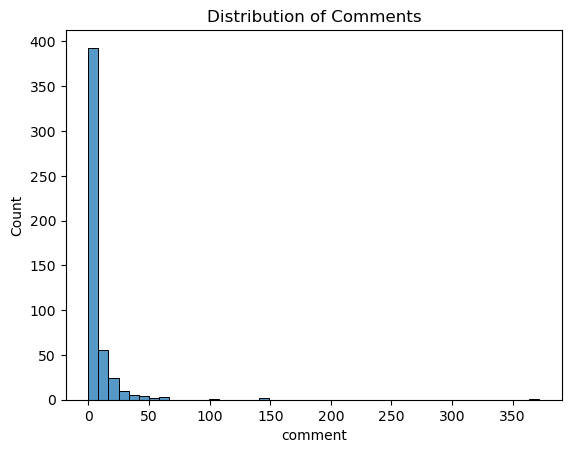

In [24]:
plt.figure()
sns.histplot(df['comment'])
plt.title("Distribution of Comments")
plt.show()

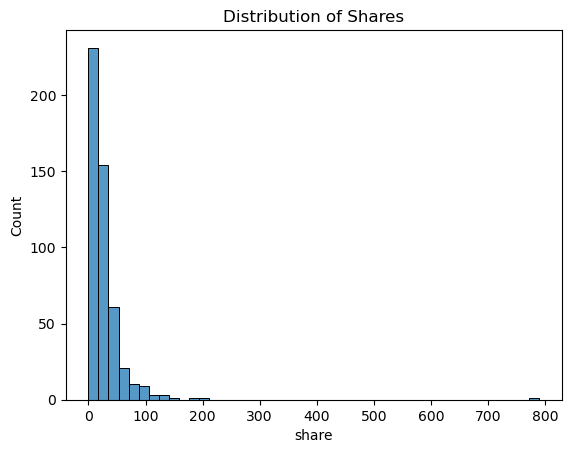

In [25]:
plt.figure()
sns.histplot(df['share'])
plt.title("Distribution of Shares")
plt.show()

The distribution of the four key measures (interactions, like, comment and share) are all right skewed. This means there are very few posts that have gone viral and created an outlier. Performance of most post are pretty consistent in terms of low interactions.

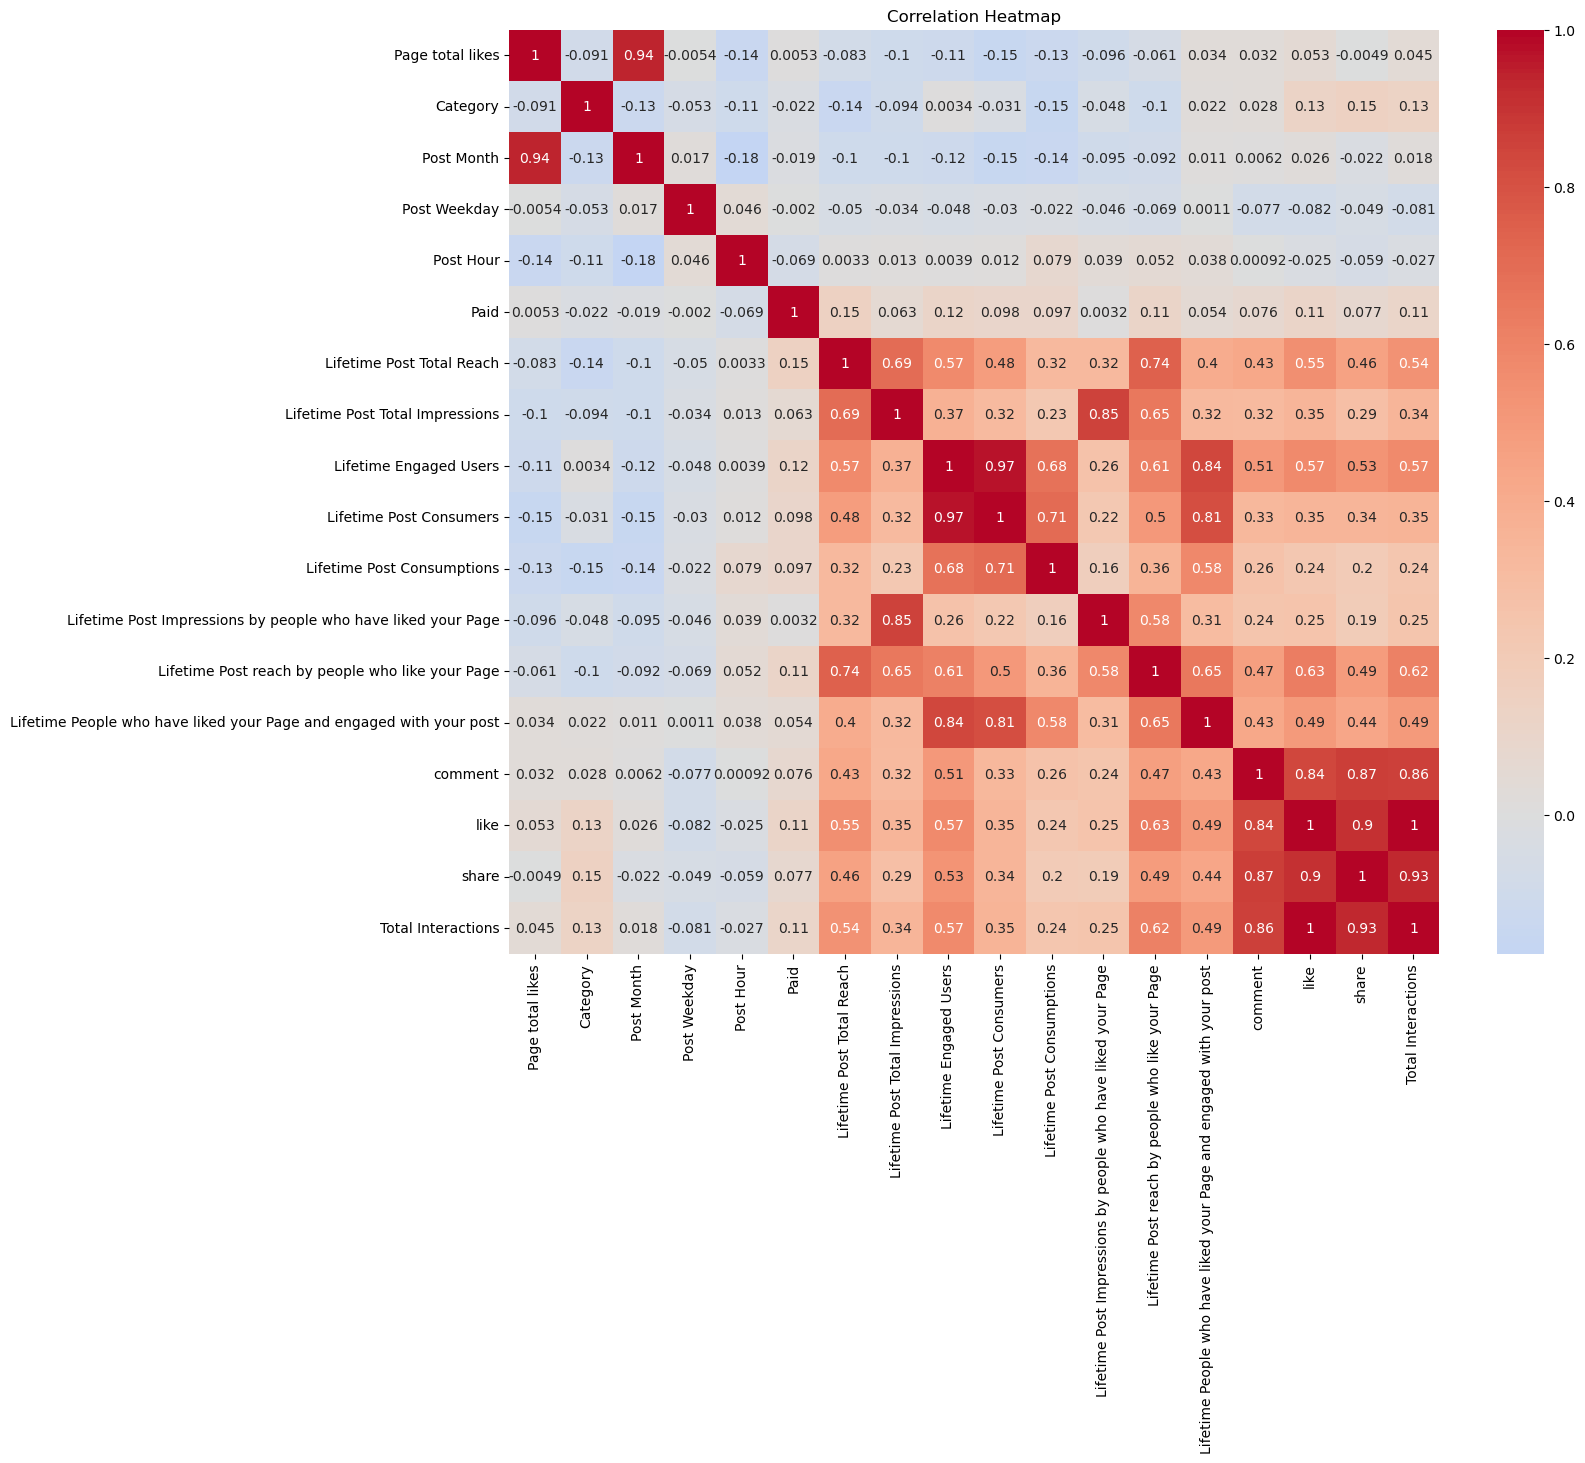

In [12]:
plt.figure(figsize=(15,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

Observations: 
1. The Heatmap shows the relation of 2 variables.
2. It's obvious that comment, like, and share are very bright because these variables makes up the total interactions, they are directly correlated.
3. Looking at the total reach, total impression and engage users, they are seem to be medium to bright colors. This means that posts that reach more people, tend to get more engagement.
4. Interestingly, paid post has a darker color in interactions. This means that paid post doesnt really mean more iengagements.
